# 02 — Análise exploratória de dados

**Secções da dissertação:** 3.5.1 (amostra, limiar, censura à direita) e 3.5.2
(descrição do alfabeto de movimentos e dados em falta).

Produz o quadro filtrado `processos_eda.parquet` e sugere — *sem fechar* — o
limiar mínimo de movimentos e o ano-base da normalização (pontos em aberto).


In [1]:
# Arranque reproduzível: funciona a partir da raiz ou de notebooks/.
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

def raiz_projeto() -> Path:
    cwd = Path.cwd().resolve()
    for cand in (cwd, cwd.parent, Path(".").resolve()):
        if (cand / "src" / "config.py").exists():
            return cand
    raise RuntimeError("Não encontrei a raiz do projecto (pasta src/).")

RAIZ = raiz_projeto()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.caminhos import garantir_directorias
from src.config import aviso_parametros_pendentes, parametros_efectivos
from src.graficos_apa import CatalogoAPA, aplicar_estilo_apa, formatar_p

DIRS = garantir_directorias(RAIZ)
PARAM = parametros_efectivos(DIRS["processado"])
aplicar_estilo_apa()

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 88)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)

print(aviso_parametros_pendentes(PARAM))
print("Raiz:", RAIZ)


AVISO METODOLÓGICO — parâmetros ainda não validados com o orientador.
  Limiar mínimo de movimentos: 5 (fallback provisório (config.py))
  Ano-base da normalização: None (ainda indefinido — será a primeira coorte observada)
  Coortes: (derivar dos dados) (derivar dos dados em tempo de execução)
  O índice produzido nesta corrida é operacional, não a versão final da dissertação.
Raiz: /workspace


In [2]:
from IPython.display import display
from src.sequencias import aplicar_exclusao_listwise, preparar_quadro_sequencias
from src.complexidade_lz import complexidade_lz

parquet = DIRS["processado"] / "processos.parquet"
if not parquet.exists():
    raise FileNotFoundError(
        f"Artefacto em falta: {parquet}. Corra 01_diagnostico_schema.ipynb primeiro."
    )
processos = pd.read_parquet(parquet)
catalogo = CatalogoAPA(
    DIRS["figuras"], DIRS["tabelas"],
    DIRS["saidas"] / "relatorio_resultados.md",
    reiniciar_relatorio=False,
)
print("Processos carregados:", len(processos))


Processos carregados: 6300


## Volume, cobertura e período

Classe, tribunal, grau e formato **não entram no índice** (secção 3.4). Servem
para descrever a amostra e, mais tarde, como controlos da validação. A coorte
é o **ano de ajuizamento**, não o ano da baixa: o painel descreve a entrada
no sistema.


In [3]:
quadro = preparar_quadro_sequencias(processos)

n_total = len(quadro)
periodo = (
    quadro["data_ajuizamento"].min(),
    quadro["data_ajuizamento"].max(),
)
print(f"N processos: {n_total}")
print(f"dataAjuizamento min/máx: {periodo[0]} — {periodo[1]}")
print("Tribunais:", quadro["tribunal"].value_counts().to_dict())
print("Graus:", quadro["grau"].value_counts().to_dict())

por_grau = (
    quadro.groupby("grau", dropna=False)
    .size().rename("n").reset_index()
    .assign(pct=lambda d: 100 * d["n"] / d["n"].sum())
)
catalogo.nova_tabela(
    por_grau,
    titulo="Distribuição dos processos por grau de jurisdição",
    nota="G1 = 1.º grau; G2 = 2.º grau; JE = Juizado Especial; TR = Turma Recursal. Extração TRF2, baixa definitiva em 2025.",
    nome_ficheiro="tabela_volume_por_grau",
    interpretacao="A amostra de trabalho concentra-se no 1.º grau e no Juizado Especial; o 2.º grau é residual e deve ser lido com cautela nas desagregações.",
)

por_classe = (
    quadro.groupby(["classe_codigo", "classe_nome"], dropna=False)
    .size().rename("n").reset_index()
    .sort_values("n", ascending=False)
    .head(12)
)
por_classe["pct"] = 100 * por_classe["n"] / n_total
catalogo.nova_tabela(
    por_classe,
    titulo="Doze classes processuais mais frequentes na amostra",
    nota="Classe segundo a Tabela Processual Unificada (TPU). Não entra no ICP (secção 3.4).",
    nome_ficheiro="tabela_top_classes",
    interpretacao="A composição por classe (execução fiscal, juizado, cumprimento de sentença) é heterogénea; por isso a validação controla a classe e não a inclui no índice.",
)


N processos: 6300
dataAjuizamento min/máx: 2016-01-07 11:34:00 — 2024-12-30 13:16:37
Tribunais: {'TRF2': 6300}
Graus: {'G1': 3119, 'JE': 3002, 'G2': 115, 'TR': 64}


grau,n,pct
G1,3119.00,49.51
G2,115.00,1.83
JE,3002.00,47.65
TR,64.00,1.02


classe_codigo,classe_nome,n,pct
436.00,Procedimento do Juizado Especial Cível,1831.00,29.06
1116.00,Execução Fiscal,1527.00,24.24
12078.00,Cumprimento de Sentença contra a Fazenda Pública,935.00,14.84
156.00,Cumprimento de sentença,739.00,11.73
7.00,Procedimento Comum Cível,295.00,4.68
120.00,Mandado de Segurança Cível,225.00,3.57
12154.00,Execução de Título Extrajudicial,156.00,2.48
1118.00,Embargos à Execução Fiscal,90.00,1.43
198.00,Apelação Cível,73.00,1.16
460.00,Recurso Inominado Cível,63.00,1.00


,classe_codigo,classe_nome,n,pct
41,436,Procedimento do Juizado Especial Cível,1831,29.063492
43,1116,Execução Fiscal,1527,24.238095
55,12078,Cumprimento de Sentença contra a Fazenda Pública,935,14.841270
21,156,Cumprimento de sentença,739,11.730159
0,7,Procedimento Comum Cível,295,4.682540
16,120,Mandado de Segurança Cível,225,3.571429
58,12154,Execução de Título Extrajudicial,156,2.476190
45,1118,Embargos à Execução Fiscal,90,1.428571
25,198,Apelação Cível,73,1.158730
42,460,Recurso Inominado Cível,63,1.000000


## Comprimento da sequência de movimentos

Este histograma é o insumo directo da decisão do **limiar mínimo** (secção 3.5.1):
processos muito curtos aproximam-se do limite degenerado \(c(S) \approx l(S)\) e
não discriminam complexidade estrutural. O limiar fica em `config.py` como TODO;
aqui apenas *sugerimos* um valor a validar com o orientador.


estatística,n_movimentos
n,6300.00
média,12.75
desvio-padrão,7.65
mín,2.00
P5,5.00
P10,6.00
P25,8.00
mediana,11.00
P75,15.00
P90,23.00


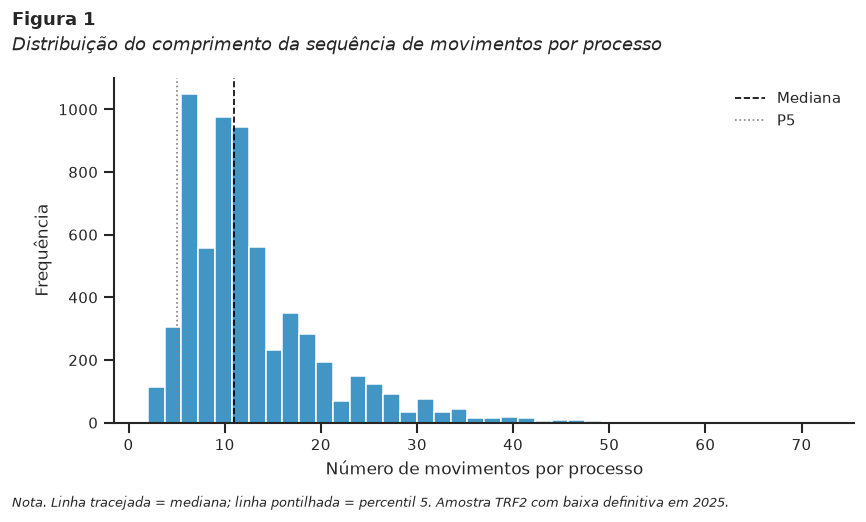

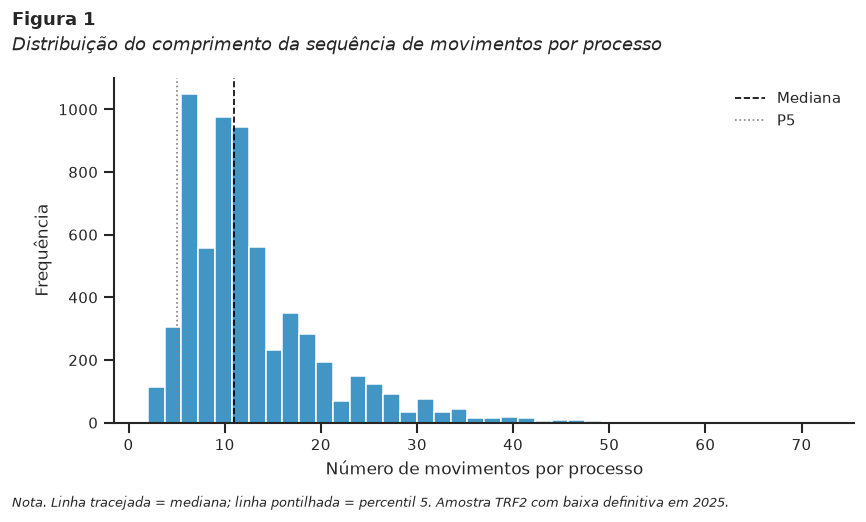

In [4]:
desc = quadro["n_movimentos"].describe(percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
estatisticas = pd.DataFrame({
    "estatística": ["n", "média", "desvio-padrão", "mín", "P5", "P10", "P25", "mediana", "P75", "P90", "P95", "máx"],
    "n_movimentos": [
        desc["count"], desc["mean"], desc["std"], desc["min"],
        desc["5%"], desc["10%"], desc["25%"], desc["50%"],
        desc["75%"], desc["90%"], desc["95%"], desc["max"],
    ],
})
catalogo.nova_tabela(
    estatisticas,
    titulo="Estatísticas descritivas do comprimento da sequência de movimentos",
    nota="Comprimento = número de movimentos com código TPU após ordenação temporal. Não é duração em dias.",
    nome_ficheiro="tabela_descritivas_comprimento",
    interpretacao="O comprimento mediano e os percentis inferiores informam o limiar mínimo: abaixo de P5–P10 a sequência é demasiado curta para c(S) se afastar de n.",
)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
sns.histplot(quadro["n_movimentos"], bins=40, ax=ax, color=sns.color_palette("colorblind")[0], edgecolor="white")
ax.set_xlabel("Número de movimentos por processo")
ax.set_ylabel("Frequência")
ax.axvline(desc["50%"], color="black", linestyle="--", linewidth=1, label="Mediana")
ax.axvline(desc["5%"], color="gray", linestyle=":", linewidth=1, label="P5")
ax.legend(frameon=False)
catalogo.nova_figura(
    fig,
    titulo="Distribuição do comprimento da sequência de movimentos por processo",
    nota="Linha tracejada = mediana; linha pontilhada = percentil 5. Amostra TRF2 com baixa definitiva em 2025.",
    nome_ficheiro="figura_histograma_comprimento_sequencia",
    interpretacao="A distribuição é assimétrica à direita: a maioria dos processos tem dezenas de movimentos, mas a cauda esquerda (sequências muito curtas) é a que justifica o limiar de exclusão da secção 3.5.1.",
)


Para ancorar o limiar, calculamos \(c(S)/n\) por comprimento: quando esta razão
se aproxima de 1, cada movimento é uma componente nova e c(S) deixa de
discriminar. Sugerimos o menor n em que a mediana de c(S)/n cai abaixo de 0,90,
com piso em 5 (fallback de `config.py`).


In [5]:
amostra_razao = quadro.loc[quadro["n_movimentos"] >= 1, ["sequencia_codigos", "n_movimentos"]].copy()
amostra_razao["c_s"] = amostra_razao["sequencia_codigos"].map(complexidade_lz)
amostra_razao["c_sobre_n"] = amostra_razao["c_s"] / amostra_razao["n_movimentos"]
por_n = (
    amostra_razao.groupby("n_movimentos")["c_sobre_n"]
    .median()
    .reset_index()
    .rename(columns={"c_sobre_n": "mediana_c_sobre_n"})
)
candidatos = por_n.loc[por_n["mediana_c_sobre_n"] < 0.90, "n_movimentos"]
sugerido_empirico = int(candidatos.min()) if len(candidatos) else 5
limiar_sugerido = max(5, sugerido_empirico)
print(f"Menor n com mediana c(S)/n < 0.90: {sugerido_empirico}")
print(f"Limiar sugerido (piso 5): {limiar_sugerido}")
display(por_n.head(15))


Menor n com mediana c(S)/n < 0.90: 7
Limiar sugerido (piso 5): 7


,n_movimentos,mediana_c_sobre_n
0,2,1.000000
1,3,1.000000
2,4,1.000000
3,5,1.000000
4,6,1.000000
5,7,0.857143
6,8,0.750000
7,9,0.777778
8,10,0.800000
9,11,0.727273


## Dimensão do alfabeto de códigos de movimento

O alfabeto global α entra no majorante teórico de c(S) (Teorema 2). O alfabeto
*local* (k por processo) é o denominador de H̄. Os dois não se confundem.


α (códigos distintos na amostra): 114


estatística,valor
n,6300.00
média,7.86
desvio-padrão,2.37
mín,2.00
P5,4.00
P25,6.00
mediana,7.00
P75,9.00
P95,12.00
máx,17.00


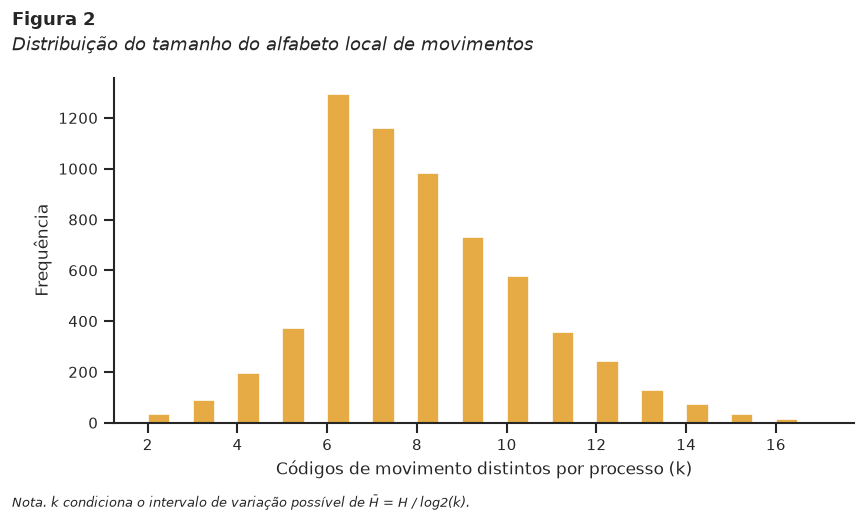

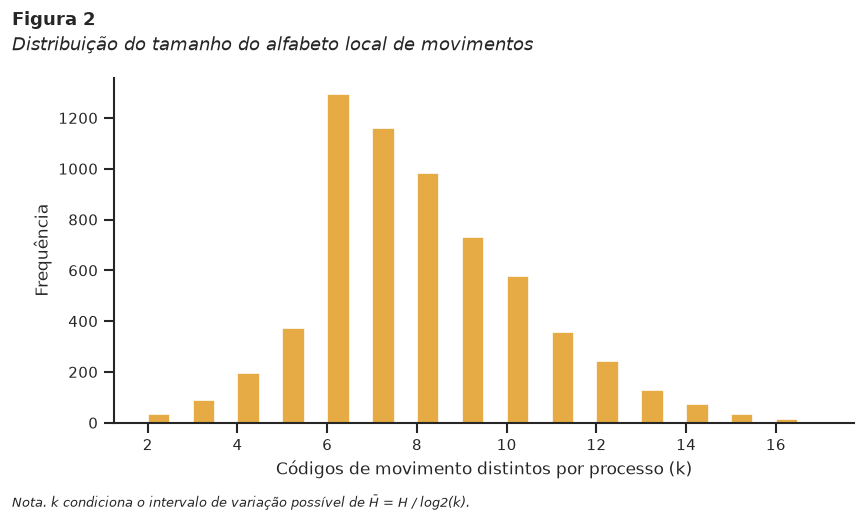

In [6]:
alfabeto = set()
for seq in quadro["sequencia_codigos"]:
    alfabeto.update(seq or [])
print("α (códigos distintos na amostra):", len(alfabeto))

desc_k = quadro["k_alfabeto_processo"].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
tab_k = pd.DataFrame({
    "estatística": ["n", "média", "desvio-padrão", "mín", "P5", "P25", "mediana", "P75", "P95", "máx", "α global"],
    "valor": [
        desc_k["count"], desc_k["mean"], desc_k["std"], desc_k["min"],
        desc_k["5%"], desc_k["25%"], desc_k["50%"], desc_k["75%"], desc_k["95%"],
        desc_k["max"], len(alfabeto),
    ],
})
catalogo.nova_tabela(
    tab_k,
    titulo="Diversidade de códigos de movimento: por processo e na amostra",
    nota="k = códigos distintos na tramitação de um processo; α = união de todos os códigos da amostra. α é o parâmetro do Teorema 2 (Lempel & Ziv, 1976).",
    nome_ficheiro="tabela_alfabeto_movimentos",
    interpretacao="k local é tipicamente muito menor do que α: a equitabilidade de Pielou (H̄) compara cada processo ao seu próprio máximo, não ao alfabeto TPU completo.",
)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
sns.histplot(quadro["k_alfabeto_processo"], bins=30, ax=ax, color=sns.color_palette("colorblind")[1], edgecolor="white")
ax.set_xlabel("Códigos de movimento distintos por processo (k)")
ax.set_ylabel("Frequência")
catalogo.nova_figura(
    fig,
    titulo="Distribuição do tamanho do alfabeto local de movimentos",
    nota="k condiciona o intervalo de variação possível de H̄ = H / log2(k).",
    nome_ficheiro="figura_histograma_alfabeto_local",
    interpretacao="A maior parte dos processos usa um subconjunto pequeno do alfabeto TPU; por isso H bruto cresceria mecanicamente com k, e a normalização intra-processo é necessária.",
)


## Dados em falta e exclusão listwise

Só se exclui o que impede o cálculo do índice: sequência ausente/corrompida ou
abaixo do limiar. Classe ou data em falta *não* excluem do ICP (não são insumos);
contabilizam-se aqui para transparência e para a validação (duração).


In [7]:
faltas = pd.DataFrame({
    "campo": [
        "sequência de movimentos vazia",
        "classe",
        "dataAjuizamento",
        "tribunal",
        "grau",
        "formato",
        "órgão julgador",
        "duração observada não calculável",
    ],
    "n_em_falta": [
        int((quadro["n_movimentos"] <= 0).sum()),
        int(quadro["classe_nome"].isna().sum()),
        int(quadro["data_ajuizamento"].isna().sum()),
        int(quadro["tribunal"].isna().sum()),
        int(quadro["grau"].isna().sum()),
        int(quadro["formato_nome"].isna().sum()),
        int(quadro["orgao_nome"].isna().sum()),
        int(quadro["duracao_dias"].isna().sum()),
    ],
})
faltas["pct"] = 100 * faltas["n_em_falta"] / len(quadro)
catalogo.nova_tabela(
    faltas,
    titulo="Percentagem de processos com campos em falta",
    nota="A exclusão listwise do índice aplica-se apenas à sequência de movimentos. Os restantes campos são controlos ou o critério externo (duração).",
    nome_ficheiro="tabela_dados_em_falta",
    interpretacao="Se a sequência está quase sempre presente, o filtro que realmente muda N é o limiar mínimo, não a corrupção de dados.",
)

limiar = int(PARAM["LIMIAR_MINIMO_MOVIMENTOS"] or limiar_sugerido)
# Se config ainda é o fallback, preferir a sugestão empírica desta EDA.
if PARAM["origem_limiar"].startswith("fallback"):
    limiar = limiar_sugerido
print("Limiar usado nesta corrida:", limiar, "| origem config:", PARAM["origem_limiar"])

filtrado, fluxo = aplicar_exclusao_listwise(quadro, limiar)
catalogo.nova_tabela(
    fluxo,
    titulo="Fluxo de exclusão listwise até à amostra de construção do índice",
    nota=f"Limiar mínimo = {limiar} movimentos (sugestão de arranque; secção 3.5.1). Não é decisão definitiva.",
    nome_ficheiro="tabela_fluxo_exclusao",
    interpretacao="O fluxo n inicial → excluídos por sequência vazia → excluídos pelo limiar → n final é o denominador de todos os resultados posteriores.",
)


campo,n_em_falta,pct
sequência de movimentos vazia,0.00,0.00
classe,0.00,0.00
dataAjuizamento,0.00,0.00
tribunal,0.00,0.00
grau,0.00,0.00
formato,0.00,0.00
órgão julgador,0.00,0.00
duração observada não calculável,0.00,0.00


Limiar usado nesta corrida: 7 | origem config: fallback provisório (config.py)


etapa,n,n_remanescente,pct_do_inicial
n inicial,6300.00,6300.00,100.00
excluídos: sequência de movimentos ausente ou vazia,0.00,6300.00,100.00
excluídos: n movimentos < limiar mínimo,1053.00,5247.00,83.29
n final (amostra do índice),5247.00,5247.00,83.29


,etapa,n,n_remanescente,pct_do_inicial
0,n inicial,6300,6300,100.000000
1,excluídos: sequência de movimentos ausente ou vazia,0,6300,100.000000
2,excluídos: n movimentos < limiar mínimo,1053,5247,83.285714
3,n final (amostra do índice),5247,5247,83.285714


## Processos em curso versus encerrados

A API pública não traz um campo canónico de situação. Inferimos encerramento
pela presença de movimentos terminais tabelados (código 22, Baixa Definitiva;
246, Arquivamento Definitivo). Processos em curso têm sequência **censurada à
direita** (secção 3.5.1): o ICP continua definido, a duração observada está
truncada. Esta extração foi desenhada com baixa em 2025, portanto espera-se
predominância de encerrados.


In [8]:
estado = (
    quadro.assign(estado=np.where(quadro["encerrado"], "encerrado", "em curso"))
    .groupby("estado").size().rename("n").reset_index()
)
estado["pct"] = 100 * estado["n"] / estado["n"].sum()
catalogo.nova_tabela(
    estado,
    titulo="Proporção de processos encerrados e em curso (inferência por movimento terminal)",
    nota="Encerrado = presença de movimento 22 (Baixa Definitiva) ou 246 (Arquivamento Definitivo), ou nome equivalente. Inferência, não campo nativo da API.",
    nome_ficheiro="tabela_encerrado_vs_em_curso",
    interpretacao="Numa extração filtrada por baixa definitiva, a censura à direita deve ser residual; se aparecerem processos «em curso», vale inspeccionar códigos terminais não previstos em config.py.",
)

ano_base_sugerido = int(filtrado["coorte"].min())
coortes = sorted(
    (str(t), int(a))
    for t, a in filtrado.dropna(subset=["tribunal", "coorte"])[["tribunal", "coorte"]].drop_duplicates().itertuples(index=False)
)
sugeridos = {
    "LIMIAR_MINIMO_MOVIMENTOS": int(limiar),
    "ANO_BASE": ano_base_sugerido,
    "COORTES": coortes,
    "justificacao_limiar": (
        f"Piso 5 combinado com o menor n cuja mediana de c(S)/n < 0.90 "
        f"(n={sugerido_empirico} nesta amostra). P5 do comprimento = {float(desc['5%']):.1f}."
    ),
    "justificacao_ano_base": (
        "Primeira coorte de ajuizamento observada na amostra filtrada "
        "(secção 3.5.3). Substituir por 2019 se essa for a coorte-base da dissertação."
    ),
    "n_inicial": int(len(quadro)),
    "n_final": int(len(filtrado)),
    "alpha_alfabeto_global": int(len(alfabeto)),
}
import json
(DIRS["processado"] / "parametros_sugeridos.json").write_text(
    json.dumps(sugeridos, ensure_ascii=False, indent=2), encoding="utf-8"
)
filtrado.to_parquet(DIRS["processado"] / "processos_eda.parquet", index=False)
print("Ano-base sugerido:", ano_base_sugerido)
print("N final:", len(filtrado))
print("Coortes:", coortes)


estado,n,pct
encerrado,6300.00,100.00


Ano-base sugerido: 2016
N final: 5247
Coortes: [('TRF2', 2016), ('TRF2', 2017), ('TRF2', 2018), ('TRF2', 2019), ('TRF2', 2020), ('TRF2', 2021), ('TRF2', 2022), ('TRF2', 2023), ('TRF2', 2024)]


## Síntese

- N inicial, período de ajuizamento e composição por grau/classe estão tabelados (APA).
- Limiar mínimo de movimentos **sugerido** nesta corrida: o valor gravado em `parametros_sugeridos.json` (ver secção 8 / `config.py` para confirmação com o orientador).
- α (alfabeto global) e a distribuição de k local condicionam H̄ e o Teorema 2.
- Exclusão listwise documentada no fluxo n inicial → n final.
- Artefacto: `data/processado/processos_eda.parquet`.
